<a href="https://colab.research.google.com/github/francielekreff/crop-recomendation/blob/main/crop_recomendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Crop Recommendation Based on Soil Data

Understanding soil characteristics is important for sustainable agriculture and optimizing crop production.

The crop recommendation based on soil analysis helps farmers to:

*   **Optimize Yields**: Plant crops that naturally thrive in the existing soil environment, leading to better growth and higher productivity.

*   **Efficient Resource Use**: Avoid wasting resources (water, fertilizers) on crops that are ill-suited for the soil.

*   **Prevent Nutrient Imbalances**: Match crop needs with soil nutrient availability, promoting healthy plant development and preventing deficiencies or toxicities.

*   **Sustainable Farming**: Reduce environmental impact by making informed decisions that minimize the need for excessive interventions.

### Crop Recomendation Dataset

Dataset link on Kaggle:
[https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset)

The dataset contains information related to crop recommendation. It includes environmental parameters and the recommended crop.

The columns are:

*   `N`: Nitrogen content in the soil
*   `P`: Phosphorus content in the soil
*   `K`: Potassium content in the soil
*   `temperature`: Temperature in Celsius
*   `humidity`: Relative humidity in %
*   `ph`: pH value of the soil
*   `rainfall`: Rainfall in mm
*   `label`: The recommended crop (target variable)

### **Load Dataset**


In [ ]:
import kagglehub
import pandas as pd
import os

# Download dataset using kagglehub
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'Crop_recommendation.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first rows of the DataFrame
display(df.head())


100%|██████████| 63.7k/63.7k [00:00<00:00, 43.0MB/s]

Extracting files...


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### **EDA (Exploratory Data Analysis)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print the number of instances) and attributes in DataFrame
print(f"Number of instances: {df.shape[0]}")
print(f"Total number of attributes (including target): {df.shape[1]}")
print()

# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Print the number of numerical and categorical attributes
print(f"Number of numerical attributes: {len(numeric_cols)}")
print(f"Number of categorical attributes: {len(categorical_cols)}")
print()


Number of instances: 2200
Total number of attributes (including target): 8

Number of numerical attributes: 7
Number of categorical attributes: 1



#### Target Variable Distribution

Distribution of the target variable, `label`.

Number of unique classes:
22

Distribution of Crop Labels:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64



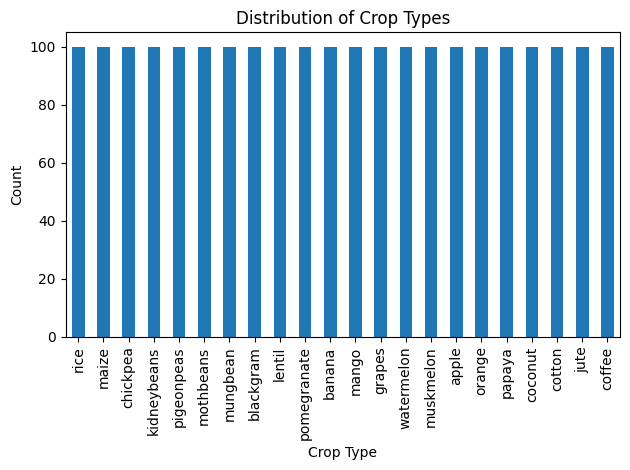

In [ ]:
# Print the number of unique classes in label
print("Number of unique classes:")
print(df['label'].nunique())
print()

# Get and print the count of each unique label
print("Distribution of Crop Labels:")
print(df['label'].value_counts())
print()

# Visualize the distribution of the target variable
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Crop Types')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#### Distribution of Numerical Features

Distribution of the numerical features, `N`, `P`, `K`, `temperature`, `humidity`, `ph` and `rainfall`

Missing values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Descriptive statistics:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


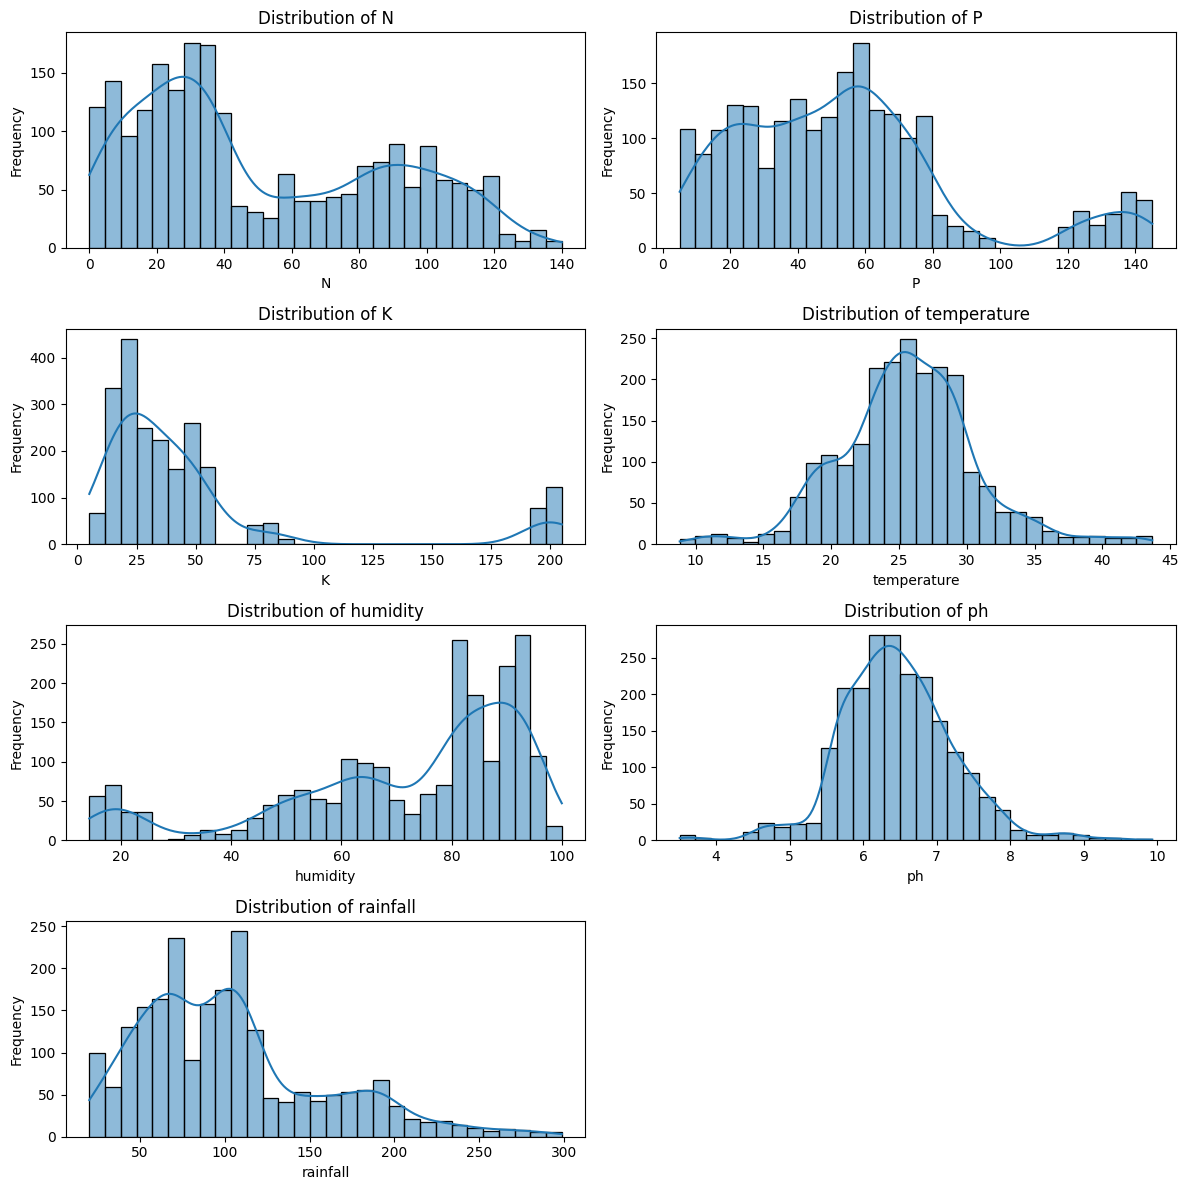

In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print()

# Display descriptive statistics for numerical columns
print("Descriptive statistics:")
display(df.describe())
print()

numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(12, 12)) # Increased figure size for better readability with 2 plots per row
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 2, i + 1) # Changed subplot grid to 4 rows, 2 columns
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### **Spot Checking**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np

# Separate features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

# Define the cross-validation strategy
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create a pipeline for KNN
k_neighbors_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Create a pipeline for Naive Bayes
naive_bayes_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

# Create a pipeline for Support Vector Machine (SVM)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# Create a pipeline for Random Forest
random_forest_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Create a pipeline for Gradient Boosting
gradient_boosting_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(random_state=42))
])

# Perform cross-validation for KNN using the pipeline
k_neighbors_scores = cross_val_score(k_neighbors_pipeline, X, y, cv=kf, scoring='accuracy')
print(f"KNN Cross-Validation Accuracy: {np.mean(k_neighbors_scores):.4f} (+/- {np.std(k_neighbors_scores):.4f})")

# Perform cross-validation for Naive Bayes using the pipeline
naive_bayes_scores = cross_val_score(naive_bayes_pipeline, X, y, cv=kf, scoring='accuracy')
print(f"Naive Bayes Cross-Validation Accuracy: {np.mean(naive_bayes_scores):.4f} (+/- {np.std(naive_bayes_scores):.4f})")

# Perform cross-validation for SVM using the pipeline
svm_scores = cross_val_score(svm_pipeline, X, y, cv=kf, scoring='accuracy')
print(f"SVM Cross-Validation Accuracy: {np.mean(svm_scores):.4f} (+/- {np.std(svm_scores):.4f})")

# Perform cross-validation for Random Forest using the pipeline
random_forest_scores = cross_val_score(random_forest_pipeline, X, y, cv=kf, scoring='accuracy')
print(f"Random Forest Cross-Validation Accuracy: {np.mean(random_forest_scores):.4f} (+/- {np.std(random_forest_scores):.4f})")

# Perform cross-validation for Gradient Boosting using the pipeline
gradient_boosting_scores = cross_val_score(gradient_boosting_pipeline, X, y, cv=kf, scoring='accuracy')
print(f"Gradient Boosting Cross-Validation Accuracy: {np.mean(gradient_boosting_scores):.4f} (+/- {np.std(gradient_boosting_scores):.4f})")


KNN Cross-Validation Accuracy: 0.9714 (+/- 0.0068)
Naive Bayes Cross-Validation Accuracy: 0.9945 (+/- 0.0018)
SVM Cross-Validation Accuracy: 0.9836 (+/- 0.0044)
Random Forest Cross-Validation Accuracy: 0.9955 (+/- 0.0032)
Gradient Boosting Cross-Validation Accuracy: 0.9909 (+/- 0.0045)


### **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Random Forest Hyperparameter Tuning
print("Starting hyperparameter tuning for Random Forest...")

# Define the search space for Random Forest
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200], # Number of trees in the forest
    'rf__max_depth': [None, 10, 20],    # Maximum tree depth
    'rf__min_samples_leaf': [1, 2, 4]   # Minimum number of samples required to be at a leaf node
}

# Creates the GridSearchCV
grid_search_rf = GridSearchCV(random_forest_pipeline, param_grid_rf, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

# Executes the grid search
grid_search_rf.fit(X, y)

print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best accuracy for Random Forest: {grid_search_rf.best_score_:.4f}")
print()

# Gradient Boosting Hyperparameter Tuning
print("Starting hyperparameter tuning for Gradient Boosting...")

# Define the search space for Gradient Boosting
param_grid_gb = {
    'gb__n_estimators': [50, 100, 200],    # Number of boosting stages
    'gb__learning_rate': [0.05, 0.1, 0.2], # Learning rate
    'gb__max_depth': [3, 5, 7]             # Maximum depth of individual estimators
}

# Creates the GridSearchCV
grid_search_gb = GridSearchCV(gradient_boosting_pipeline, param_grid_gb, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

# Executes the grid search
grid_search_gb.fit(X, y)

print(f"Best parameters for Gradient Boosting: {grid_search_gb.best_params_}")
print(f"Best accuracy for Gradient Boosting: {grid_search_gb.best_score_:.4f}")

Starting hyperparameter tuning for Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Random Forest: {'rf__max_depth': 10, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 200}
Best accuracy for Random Forest: 0.9964

Starting hyperparameter tuning for Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Gradient Boosting: {'gb__learning_rate': 0.05, 'gb__max_depth': 3, 'gb__n_estimators': 100}
Best accuracy for Gradient Boosting: 0.9936
